In [6]:
import numpy as np
import polars as pl
import re

import matplotlib.pyplot as plt

from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
from string import punctuation
import pymorphy2

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D

import pickle

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
RUS_STOPWORDS = set(stopwords.words('russian'))
PUNCT_SIGNS = punctuation + '—–…'

MORPH_AGENT = pymorphy2.MorphAnalyzer()

In [ ]:
def import_dataset(path):
    rows = []
    with open(path, encoding='utf-8') as fh:
        for line in fh:
            if not line.strip():
                continue
            meta, content = line.strip().split(' ', 1)
            tags = set(meta.split(','))

            rows.append((
                content.strip(),
                1 if '__label__NORMAL' in tags else 0,
                1 if '__label__INSULT' in tags else 0,
                1 if '__label__THREAT' in tags else 0,
                1 if '__label__OBSCENITY' in tags else 0,
            ))

    columns = ['comment', 'normal', 'insult', 'threat', 'obscenity']
    return pl.DataFrame(rows, schema=columns, orient='row')

In [ ]:
df = import_dataset("dataset.txt")
df.head(10)

comment,normal,insult,threat,obscenity
str,i64,i64,i64,i64
"""скотина! что сказать""",0,1,0,0
"""я сегодня проезжала по рабочей…",1,0,0,0
"""очередной лохотрон. зачем прид…",1,0,0,0
"""ретро дежавю ... сложно понять…",1,0,0,0
"""а когда мы статус агрогородка …",1,0,0,0
"""2 августа поздно вечером нашли…",1,0,0,0
"""вчера надыбала новые стикеры #…",1,0,0,0
"""заколоть этого плешивого урода…",0,1,1,0
"""а еще на стоянке никто не пров…",1,0,0,0


In [10]:
print(df.shape)

(248290, 5)


In [ ]:
def normalize_chat(text):
    normalized = str(text).lower().replace('ё', 'е')
    normalized = re.sub(r'http\S+|www\S+|https\S+', ' URL ', normalized)
    normalized = re.sub(r'@\w+', ' USER ', normalized)
    normalized = re.sub(r'#\w+', ' HASHTAG ', normalized)
    normalized = re.sub(r'[^а-яa-z\s]', ' ', normalized)
    normalized = re.sub(r'\s+', ' ', normalized).strip()
    return normalized

In [ ]:
from functools import lru_cache

@lru_cache(maxsize=100000)
def normalize_word(word):
    parsed = MORPH_AGENT.parse(word)
    return parsed[0].normal_form if parsed else word


def lemmatize_phrase(text):
    tokens = normalize_chat(text).split()
    clean = [normalize_word(tok) for tok in tokens if tok not in RUS_STOPWORDS and tok not in PUNCT_SIGNS and len(tok) > 2]
    return ' '.join(clean)

In [ ]:
df = df.with_columns(
    pl.col("comment").map_elements(normalize_chat, return_dtype=pl.Utf8).alias("clean_comment")
)
df.select("clean_comment").head(10)

clean_comment
str
"""скотина что сказать"""
"""я сегодня проезжала по рабочей…"
"""очередной лохотрон зачем приду…"
"""ретро дежавю сложно понять чуж…"
"""а когда мы статус агрогородка …"
"""августа поздно вечером нашли в…"
"""вчера надыбала новые стикеры"""
"""заколоть этого плешивого урода…"
"""а еще на стоянке никто не пров…"


In [ ]:
df = df.with_columns(
    pl.col("clean_comment").map_elements(lemmatize_phrase, return_dtype=pl.Utf8).alias("lemmatized_comment")
)
df.select("lemmatized_comment").head(10)

lemmatized_comment
str
"""скотина сказать"""
"""сегодня проезжать рабочий дом …"
"""очередной лохотрон придумывать…"
"""ретро дежавю сложно понять чуж…"
"""статус агрогородок получить"""
"""август поздно вечером наслать …"
"""вчера надыбал новый стикер"""
"""заколоть плешивый урод крякнут…"
"""стоянка никто проверять безопа…"


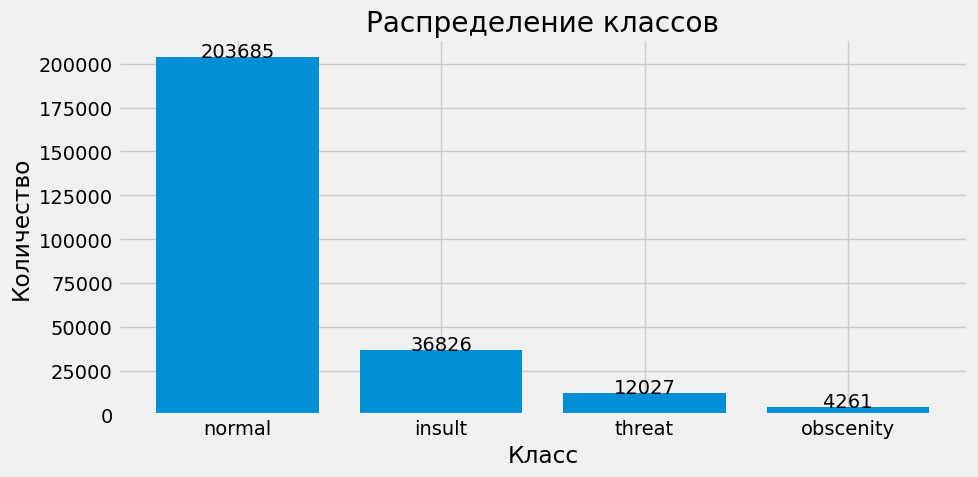

In [15]:
plt.style.use('fivethirtyeight')

fig, axe = plt.subplots(figsize=(10, 5))

class_counts = df.select(["normal", "insult", "threat", "obscenity"]).sum()
classes = class_counts.columns
values = class_counts.row(0)

axe.bar(classes, values)
axe.set_title('Распределение классов')
axe.set_xlabel('Класс')
axe.set_ylabel('Количество')
for i, v in enumerate(values):
    axe.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

In [16]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

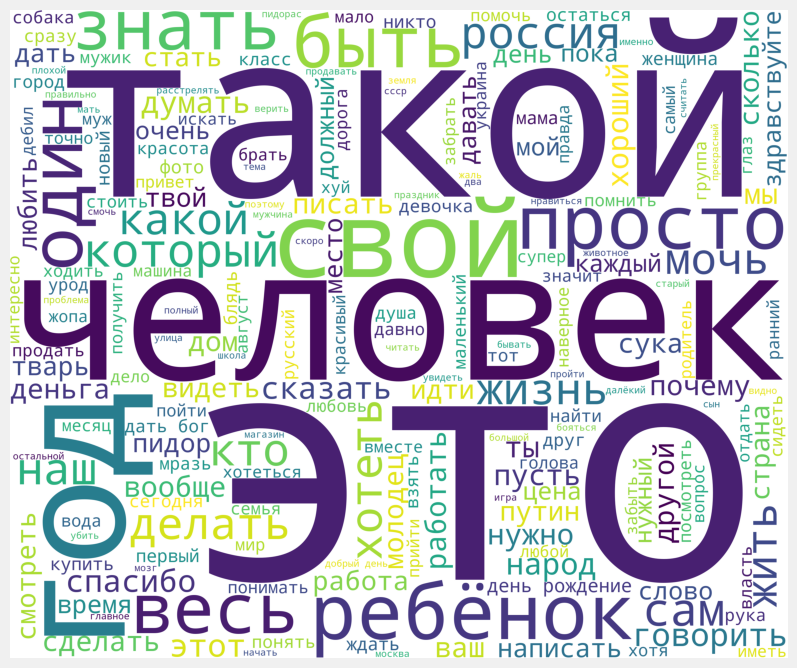

In [17]:
corpus = get_corpus(df["lemmatized_comment"].to_list())
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.show()

In [18]:
df_train, df_test = train_test_split(df, train_size=0.8, random_state=42)

In [19]:
print(df_train.shape)
print(df_test.shape)

(198632, 7)
(49658, 7)


In [20]:
feature_train = df_train.get_column('lemmatized_comment').to_numpy()
feature_test = df_test.get_column('lemmatized_comment').to_numpy()
target_train = df_train.drop(['comment', 'clean_comment', 'lemmatized_comment']).to_numpy()
target_test = df_test.drop(['comment', 'clean_comment', 'lemmatized_comment']).to_numpy()

In [21]:
vocab_size = 10000
max_length = 100
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(feature_train)

training_sequences = tokenizer.texts_to_sequences(feature_train)
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

testing_sequences = tokenizer.texts_to_sequences(feature_test)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [22]:
embedding_dim = 16

model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(24, activation='relu'),
    Dense(4, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 16)           160000    
                                                                 
 global_average_pooling1d (G  (None, 16)               0         
 lobalAveragePooling1D)                                          
                                                                 
 dense (Dense)               (None, 24)                408       
                                                                 
 dense_1 (Dense)             (None, 4)                 100       
                                                                 
Total params: 160,508
Trainable params: 160,508
Non-trainable params: 0
_________________________________________________________________


In [23]:
history = model.fit(training_padded, target_train, epochs=10, validation_data=(testing_padded, target_test), verbose=1)

Epoch 1/10
6208/6208 [==============================] - 18s 3ms/step - loss: 0.2070 - accuracy: 0.8724 - val_loss: 0.1306 - val_accuracy: 0.9230
Epoch 2/10
6208/6208 [==============================] - 19s 3ms/step - loss: 0.1156 - accuracy: 0.9316 - val_loss: 0.1104 - val_accuracy: 0.9319
Epoch 3/10
6208/6208 [==============================] - 19s 3ms/step - loss: 0.0934 - accuracy: 0.9460 - val_loss: 0.0972 - val_accuracy: 0.9440
Epoch 4/10
6208/6208 [==============================] - 19s 3ms/step - loss: 0.0822 - accuracy: 0.9513 - val_loss: 0.0933 - val_accuracy: 0.9435
Epoch 5/10
6208/6208 [==============================] - 19s 3ms/step - loss: 0.0759 - accuracy: 0.9525 - val_loss: 0.0884 - val_accuracy: 0.9467
Epoch 6/10
6208/6208 [==============================] - 19s 3ms/step - loss: 0.0700 - accuracy: 0.9541 - val_loss: 0.0854 - val_accuracy: 0.9461
Epoch 7/10
6208/6208 [==============================] - 19s 3ms/step - loss: 0.0652 - accuracy: 0.9557 - val_loss: 0.0841 - val_ac

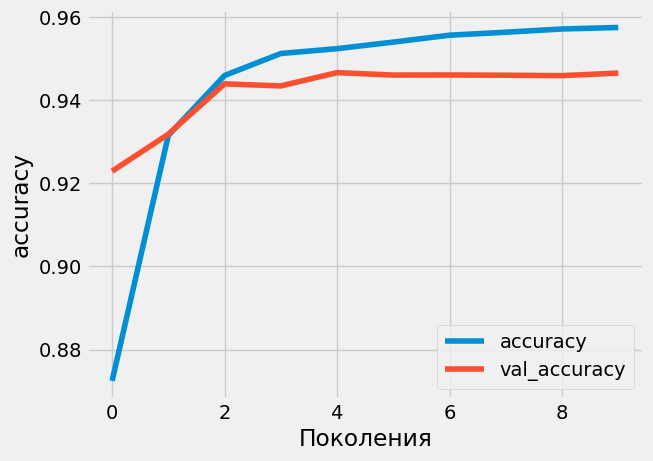

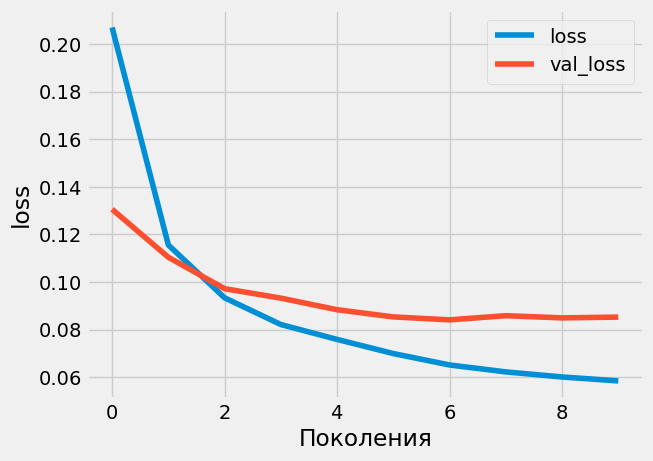

In [24]:
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Поколения")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()
  
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [25]:
model.save('toxic_model.h5')

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)